# 1D Molecular Dynamics with Velocity Verlet

This notebook implements a **1D molecular dynamics (MD)** simulation using the **Velocity Verlet** integration method.

We model particles in a 1D periodic box with Lennard-Jones interactions:
$$U(r)=4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12}-\left(\frac{\sigma}{r}\right)^6\right].$$

Velocity Verlet update equations:
$$x_{i}(t+\Delta t)=x_i(t)+v_i(t)\Delta t+\frac{1}{2}a_i(t)\Delta t^2,$$
$$v_i(t+\Delta t)=v_i(t)+\frac{1}{2}\left[a_i(t)+a_i(t+\Delta t)\right]\Delta t.$$

### Author: Joshua Clavecillas
partner: Diego 

### JC: the pseudo code equations fit the ones in the textbook, although it used the 18.20 equations instead of the one with acceleration instead of $F(t+ \Delta t)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ------------------------------
# Simulation parameters
# ------------------------------
N = 24                 # number of particles
m = 1.0                # particle mass
epsilon = 1.0          # Lennard-Jones energy scale
sigma = 1.0            # Lennard-Jones length scale
L = 40.0               # box length (1D periodic box)
rc = 2.5 * sigma       # cutoff radius
dt = 0.003             # timestep
n_steps = 8000         # total integration steps
sample_every = 20      # store every k steps for plotting

rng = np.random.default_rng(7)

In [3]:
# ------------------------------
# Initial conditions
# ------------------------------
# Start approximately on a lattice with slight random jitter
x = np.linspace(0, L, N, endpoint=False) + 0.04 * rng.normal(size=N)
x = np.mod(x, L)
x.sort()

# Random initial velocities with zero center-of-mass velocity
v = 0.45 * rng.normal(size=N)
v -= np.mean(v)

In [4]:
def minimum_image_1d(dx, box_length):
    """Apply 1D minimum-image convention for periodic boundaries."""
    return dx - box_length * np.rint(dx / box_length)

def forces_and_potential_1d(x, L, epsilon, sigma, rc):
    """Compute pair forces and potential energy in 1D with LJ + cutoff."""
    N = len(x)
    f = np.zeros_like(x)
    U = 0.0
    rc2 = rc * rc

    # Shift potential so U(rc)=0 for continuity
    inv_rc2 = 1.0 / (rc * rc)
    inv_rc6 = (sigma * sigma * inv_rc2) ** 3
    U_shift = 4.0 * epsilon * (inv_rc6 * inv_rc6 - inv_rc6)

    for i in range(N - 1):
        for j in range(i + 1, N):
            dx = minimum_image_1d(x[j] - x[i], L)
            r2 = dx * dx

            if r2 < rc2 and r2 > 1e-14:
                inv_r2 = 1.0 / r2
                s2_over_r2 = (sigma * sigma) * inv_r2
                s6_over_r6 = s2_over_r2 ** 3
                s12_over_r12 = s6_over_r6 ** 2

                # Force magnitude divided by r, times dx gives signed 1D force
                f_scalar = 24.0 * epsilon * (2.0 * s12_over_r12 - s6_over_r6) * inv_r2
                fij = f_scalar * dx

                f[i] -= fij
                f[j] += fij

                U += 4.0 * epsilon * (s12_over_r12 - s6_over_r6) - U_shift

    return f, U

In [5]:
# ------------------------------
# Velocity Verlet integration
# ------------------------------
f, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)
a = f / m

times = []
x_samples = []
KE_hist, PE_hist, TE_hist = [], [], []

for step in range(n_steps):
    # 1) Update positions
    x = x + v * dt + 0.5 * a * dt * dt
    x = np.mod(x, L)

    # 2) Compute new acceleration from new positions
    f_new, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)
    a_new = f_new / m

    # 3) Update velocities with average acceleration
    v = v + 0.5 * (a + a_new) * dt

    # 4) Move to next acceleration
    a = a_new

    # Diagnostics
    KE = 0.5 * m * np.sum(v * v)
    PE = U
    TE = KE + PE

    KE_hist.append(KE)
    PE_hist.append(PE)
    TE_hist.append(TE)

    if step % sample_every == 0:
        times.append(step * dt)
        x_samples.append(np.copy(x))

times = np.array(times)
x_samples = np.array(x_samples)

print(f"Completed {n_steps} steps.")
print(f"Initial total energy: {TE_hist[0]:.6f}")
print(f"Final total energy:   {TE_hist[-1]:.6f}")
print(f"Relative drift:       {(TE_hist[-1]-TE_hist[0])/(abs(TE_hist[0])+1e-12):.3e}")

Completed 8000 steps.
Initial total energy: -2.052587
Final total energy:   -2.053062
Relative drift:       -2.318e-04


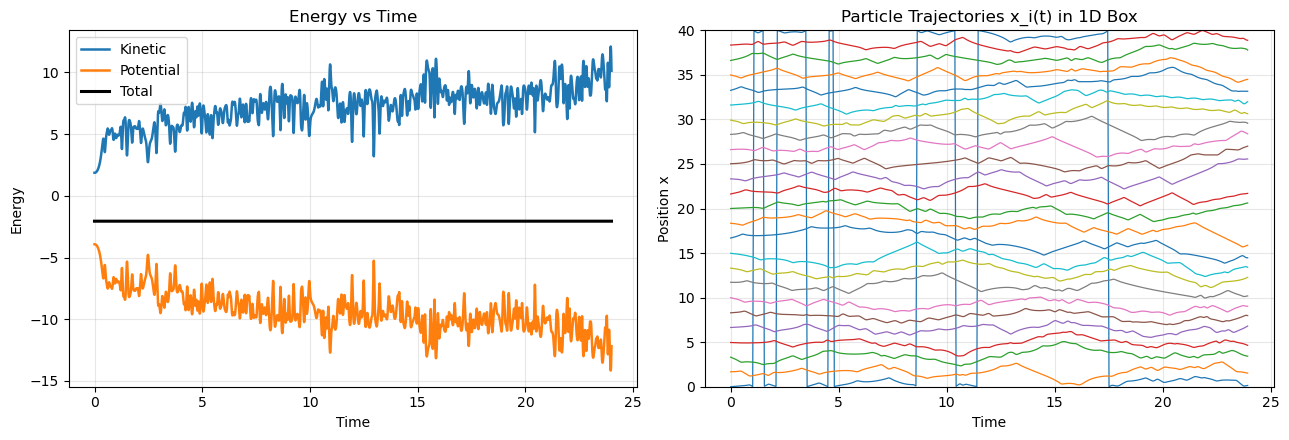

In [6]:
# ------------------------------
# Plots
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

t_full = np.arange(n_steps) * dt
axes[0].plot(t_full, KE_hist, label="Kinetic", lw=1.8)
axes[0].plot(t_full, PE_hist, label="Potential", lw=1.8)
axes[0].plot(t_full, TE_hist, label="Total", lw=2.2, color="black")
axes[0].set_title("Energy vs Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Energy")
axes[0].grid(alpha=0.3)
axes[0].legend()

for i in range(N):
    axes[1].plot(times, x_samples[:, i], lw=0.9)
axes[1].set_title("Particle Trajectories x_i(t) in 1D Box")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Position x")
axes[1].set_ylim(0, L)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### JC: The first run of everything gave out figures consistent with the behavior shown in the book, where the Kinetic is positive, potential is negative, and total energy doesnt change. This makes sense physically but i am curios as to why there is a net change in energy. This could be attributed to the large Energy values, and the percent difference would be better to compute, but from the book and lecture velocity Verlet function is one of the more accurate ways to conserve energy. Maybe I should use the velocity equation with the force as a component in the equation.

Comparison of Velocity Verlet variants
Max |Δx_final| (minimum image): 0.000e+00
Max |Δv_final|:                0.000e+00
Max |ΔE_total(t)|:             0.000e+00
Expected: near machine precision differences (methods are algebraically equivalent).


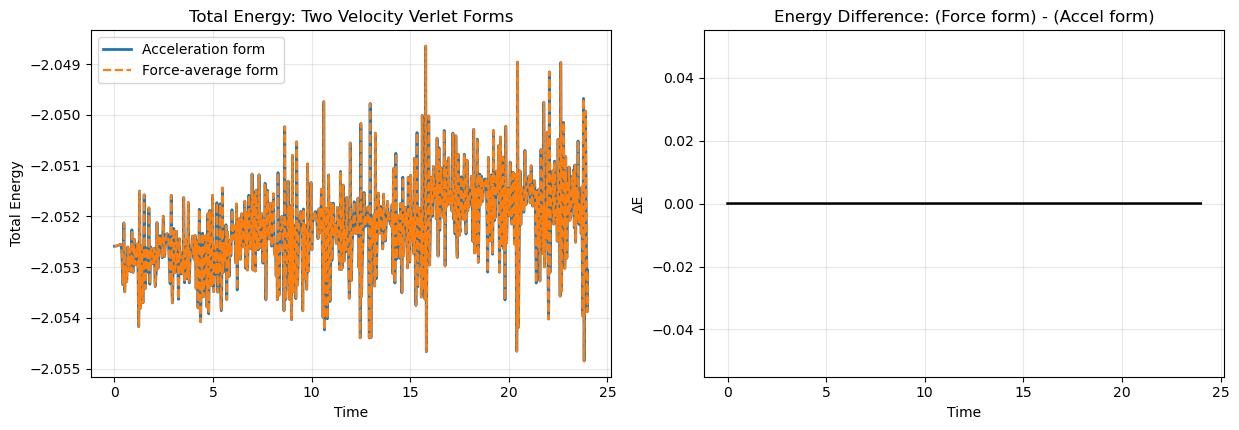

In [7]:
# Compare two equivalent Velocity Verlet velocity updates:
# (A) acceleration form: v_{n+1} = v_n + 0.5*(a_n + a_{n+1})*dt
# (B) force form from your equation: v_{n+1} = v_n + dt*(F_n + F_{n+1})/(2m)

# Rebuild identical initial conditions for a fair comparison
rng_cmp = np.random.default_rng(7)
x0_cmp = np.linspace(0, L, N, endpoint=False) + 0.04 * rng_cmp.normal(size=N)
x0_cmp = np.mod(x0_cmp, L)
x0_cmp.sort()
v0_cmp = 0.45 * rng_cmp.normal(size=N)
v0_cmp -= np.mean(v0_cmp)

def run_md_accel_form(x0, v0, n_steps, dt, m, L, epsilon, sigma, rc):
    x = x0.copy()
    v = v0.copy()

    f, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)
    a = f / m

    TE_hist = np.empty(n_steps)
    for k in range(n_steps):
        x = np.mod(x + v * dt + 0.5 * a * dt * dt, L)
        f_new, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)
        a_new = f_new / m
        v = v + 0.5 * (a + a_new) * dt
        a = a_new

        KE = 0.5 * m * np.sum(v * v)
        TE_hist[k] = KE + U

    return x, v, TE_hist

def run_md_force_form(x0, v0, n_steps, dt, m, L, epsilon, sigma, rc):
    x = x0.copy()
    v = v0.copy()

    f, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)

    TE_hist = np.empty(n_steps)
    for k in range(n_steps):
        # position update uses F_n/m
        x = np.mod(x + v * dt + 0.5 * (f / m) * dt * dt, L)

        f_new, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)

        # velocity update using the force-average equation from your image
        v = v + (dt / (2.0 * m)) * (f + f_new)

        f = f_new
        KE = 0.5 * m * np.sum(v * v)
        TE_hist[k] = KE + U

    return x, v, TE_hist

xA, vA, TE_A = run_md_accel_form(x0_cmp, v0_cmp, n_steps, dt, m, L, epsilon, sigma, rc)
xB, vB, TE_B = run_md_force_form(x0_cmp, v0_cmp, n_steps, dt, m, L, epsilon, sigma, rc)

# Periodic-position difference (minimum image)
dx_final = minimum_image_1d(xB - xA, L)
dv_final = vB - vA

print('Comparison of Velocity Verlet variants')
print(f'Max |Δx_final| (minimum image): {np.max(np.abs(dx_final)):.3e}')
print(f'Max |Δv_final|:                {np.max(np.abs(dv_final)):.3e}')
print(f'Max |ΔE_total(t)|:             {np.max(np.abs(TE_B - TE_A)):.3e}')
print('Expected: near machine precision differences (methods are algebraically equivalent).')

# Plot total energies and difference
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
t_cmp = np.arange(n_steps) * dt

axes[0].plot(t_cmp, TE_A, lw=2, label='Acceleration form')
axes[0].plot(t_cmp, TE_B, lw=1.6, ls='--', label='Force-average form')
axes[0].set_title('Total Energy: Two Velocity Verlet Forms')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Total Energy')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(t_cmp, TE_B - TE_A, lw=1.8, color='black')
axes[1].set_title('Energy Difference: (Force form) - (Accel form)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('ΔE')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### JC: hmm its both the same so its not the method, maybe just taking smaller time stepsizes. 

In [10]:
# ------------------------------
# Simulation parameters
# ------------------------------
N = 24                 # number of particles
m = 1.0                # particle mass
epsilon = 1.0          # Lennard-Jones energy scale
sigma = 1.0            # Lennard-Jones length scale
L = 40.0               # box length (1D periodic box)
rc = 2.5 * sigma       # cutoff radius
dt = 0.0001             # timestep
n_steps = 80000         # total integration steps
sample_every = 20      # store every k steps for plotting

rng = np.random.default_rng(7)

# ------------------------------
# Velocity Verlet integration
# ------------------------------
f, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)
a = f / m

times = []
x_samples = []
KE_hist, PE_hist, TE_hist = [], [], []

for step in range(n_steps):
    # 1) Update positions
    x = x + v * dt + 0.5 * a * dt * dt
    x = np.mod(x, L)

    # 2) Compute new acceleration from new positions
    f_new, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)
    a_new = f_new / m

    # 3) Update velocities with average acceleration
    v = v + 0.5 * (a + a_new) * dt

    # 4) Move to next acceleration
    a = a_new

    # Diagnostics
    KE = 0.5 * m * np.sum(v * v)
    PE = U
    TE = KE + PE

    KE_hist.append(KE)
    PE_hist.append(PE)
    TE_hist.append(TE)

    if step % sample_every == 0:
        times.append(step * dt)
        x_samples.append(np.copy(x))

times = np.array(times)
x_samples = np.array(x_samples)

print(f"Completed {n_steps} steps.")
print(f"Initial total energy: {TE_hist[0]:.6f}")
print(f"Final total energy:   {TE_hist[-1]:.6f}")
print(f"Relative drift:       {(TE_hist[-1]-TE_hist[0])/(abs(TE_hist[0])+1e-12):.3e}")

Completed 80000 steps.
Initial total energy: -2.053213
Final total energy:   -2.053214
Relative drift:       -2.017e-07


### JC: Over 80,000 steps and only a drift of 0.0000002 energy difference is pretty good and I can safely continue using this algorithm as the difference in energy has to do with the step size. Realistically I shouldve asked this question at the start but oh well. Im going to implement it so the initial velocities are based off the temperature.

Target temperature T = 1.250
Velocity scale sigma_v = sqrt(k_B T / m) = 1.118
Implied initial temperature from sampled velocities = 0.718
Initial measured temperature after first step: 0.718
Long-time mean temperature (last 30%): 1.032


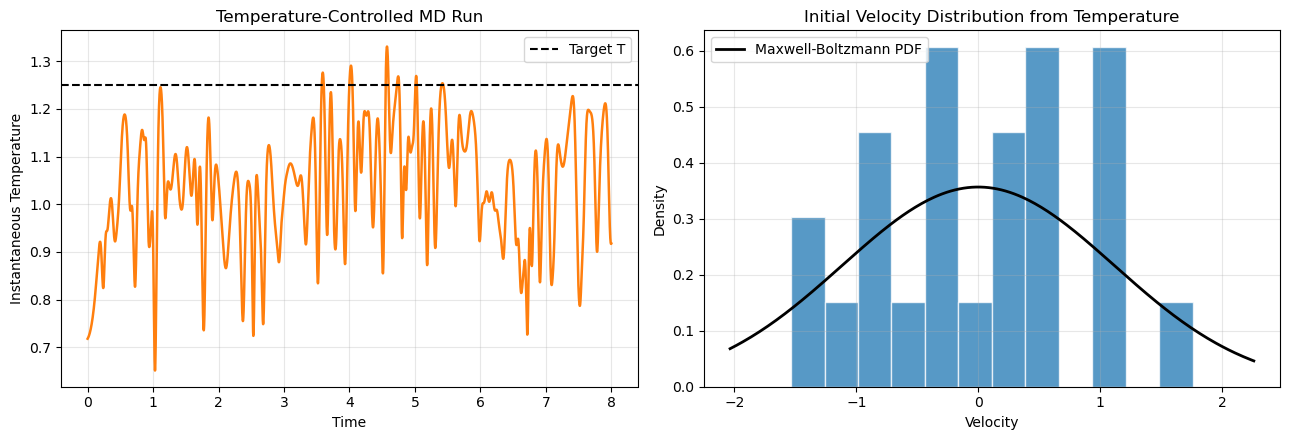

Temperature-based initialization keeps the velocity scale physically tied to T.
This is the usual MD behavior: higher T -> broader initial velocities.


In [14]:
# Temperature-controlled initialization for molecular dynamics
# In MD, temperature sets the velocity scale through the Maxwell-Boltzmann distribution.
# For 1D, the velocity standard deviation is sigma_v = sqrt(k_B T / m).

k_B = 1.0  # reduced units
T_target = 3  # explicit temperature value in reduced units
rng_temp = np.random.default_rng(21)

# Rebuild positions so this cell is self-contained and reproducible
x0_temp = np.linspace(0, L, N, endpoint=False) + 0.04 * rng_temp.normal(size=N)
x0_temp = np.mod(x0_temp, L)
x0_temp.sort()

# Maxwell-Boltzmann initial velocities in 1D
sigma_v = np.sqrt(k_B * T_target / m)
v0_temp = rng_temp.normal(loc=0.0, scale=sigma_v, size=N)
v0_temp -= np.mean(v0_temp)  # remove center-of-mass drift

# Temperature implied by the sampled velocities
T_from_v0 = m * np.mean(v0_temp**2) / k_B
print(f'Target temperature T = {T_target:.3f}')
print(f'Velocity scale sigma_v = sqrt(k_B T / m) = {sigma_v:.3f}')
print(f'Implied initial temperature from sampled velocities = {T_from_v0:.3f}')

# Run the MD simulation using the temperature-based initial velocities
x_temp, v_temp, TE_temp = run_md_accel_form(x0_temp, v0_temp, n_steps, dt, m, L, epsilon, sigma, rc)

# Instantaneous temperature from kinetic energy in 1D:
# T_inst = 2 * K / (N * k_B)
KE_hist_temp = np.empty(n_steps)
T_hist_temp = np.empty(n_steps)

# Re-run a compact copy so we can record the temperature history cleanly
x = x0_temp.copy()
v = v0_temp.copy()
f, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)
a = f / m

for step in range(n_steps):
    x = np.mod(x + v * dt + 0.5 * a * dt * dt, L)
    f_new, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)
    a_new = f_new / m
    v = v + 0.5 * (a + a_new) * dt
    a = a_new

    KE = 0.5 * m * np.sum(v * v)
    KE_hist_temp[step] = KE
    T_hist_temp[step] = 2.0 * KE / (N * k_B)

# Compare temperature-based initialization with the earlier fixed-amplitude initialization
# by looking at the starting temperature and the long-time mean temperature.
T0_measured = T_hist_temp[0]
T_tail_mean = np.mean(T_hist_temp[int(0.7 * n_steps):])

print(f'Initial measured temperature after first step: {T0_measured:.3f}')
print(f'Long-time mean temperature (last 30%): {T_tail_mean:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

t_temp = np.arange(n_steps) * dt
axes[0].plot(t_temp, T_hist_temp, lw=1.8, color='tab:orange')
axes[0].axhline(T_target, color='black', ls='--', lw=1.5, label='Target T')
axes[0].set_title('Temperature-Controlled MD Run')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Instantaneous Temperature')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].hist(v0_temp, bins=12, density=True, alpha=0.75, color='tab:blue', edgecolor='white')
vel_grid = np.linspace(v0_temp.min() - 0.5, v0_temp.max() + 0.5, 250)
mb_pdf = (1.0 / np.sqrt(2.0 * np.pi * sigma_v**2)) * np.exp(-0.5 * (vel_grid / sigma_v) ** 2)
axes[1].plot(vel_grid, mb_pdf, color='black', lw=2, label='Maxwell-Boltzmann PDF')
axes[1].set_title('Initial Velocity Distribution from Temperature')
axes[1].set_xlabel('Velocity')
axes[1].set_ylabel('Density')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Temperature-based initialization keeps the velocity scale physically tied to T.')
print('This is the usual MD behavior: higher T -> broader initial velocities.')

### Temperature sweep comparison

The next cell runs the same 1D MD model for several target temperatures and compares the resulting energy traces and particle trajectories.

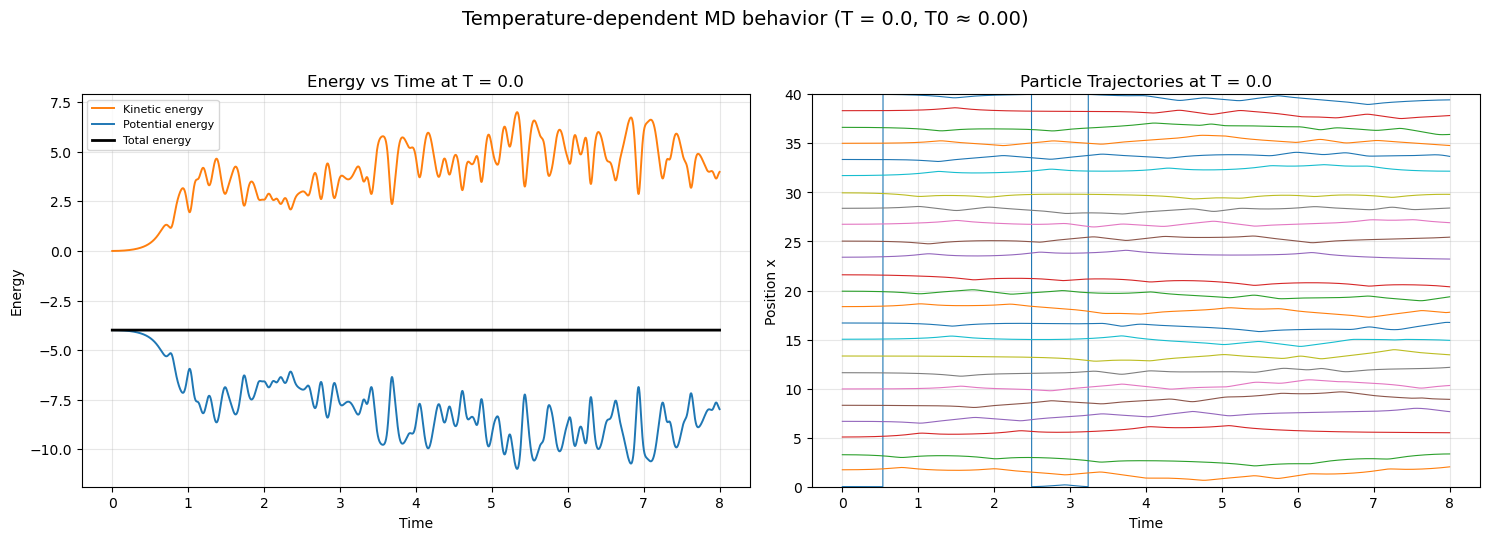

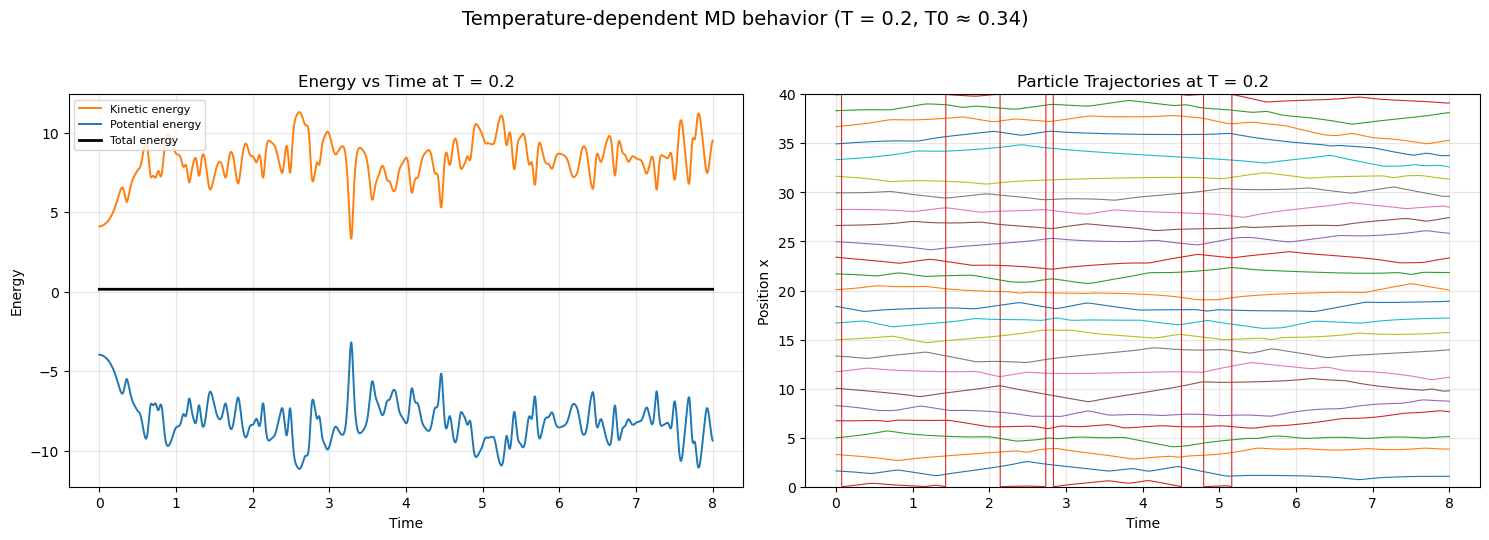

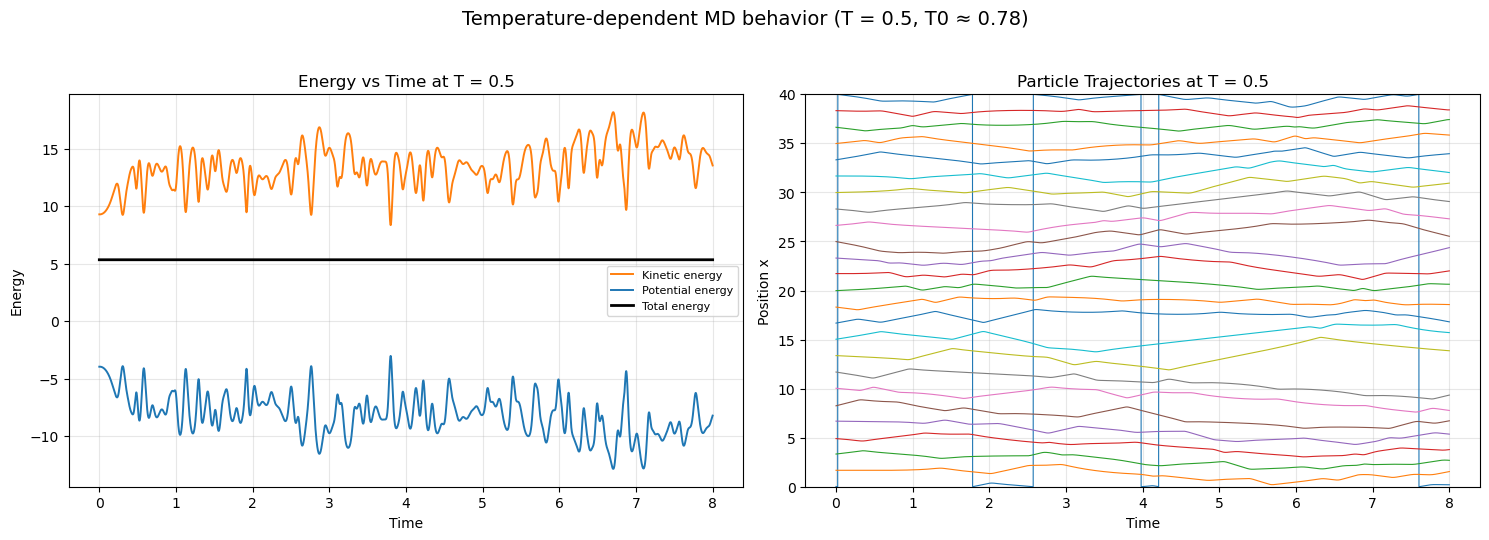

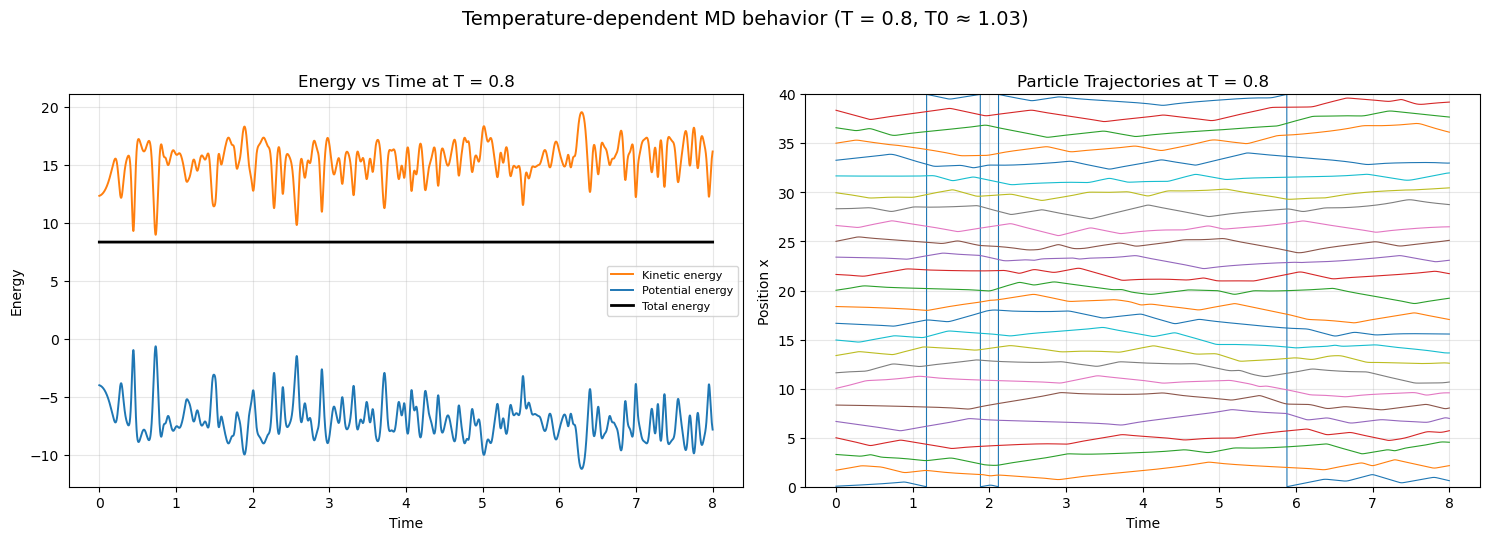

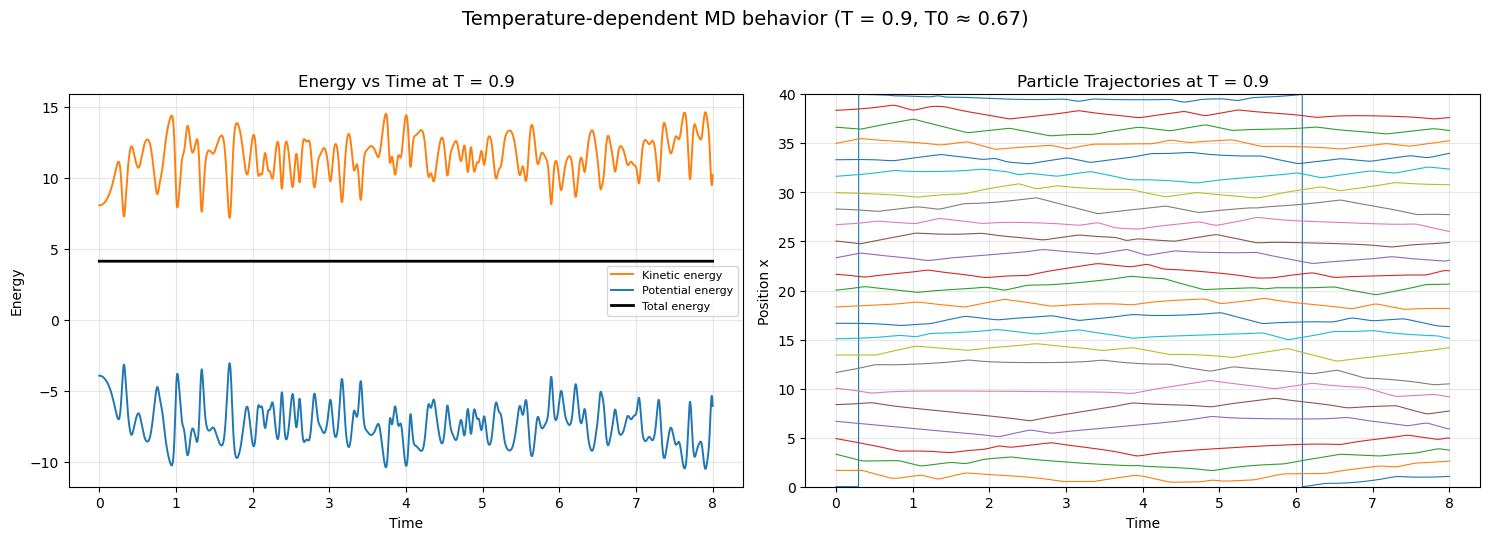

T=0.0 | sampled T0=0.000 | mean instantaneous T (last 30%)=0.412
T=0.2 | sampled T0=0.343 | mean instantaneous T (last 30%)=0.702
T=0.5 | sampled T0=0.775 | mean instantaneous T (last 30%)=1.218
T=0.8 | sampled T0=1.027 | mean instantaneous T (last 30%)=1.320
T=0.9 | sampled T0=0.673 | mean instantaneous T (last 30%)=0.977

Saved PNG files:
/Users/joshuaclavecillas/anaconda_projects/Computational_folder/md_temperature_T0p0.png
/Users/joshuaclavecillas/anaconda_projects/Computational_folder/md_temperature_T0p25.png
/Users/joshuaclavecillas/anaconda_projects/Computational_folder/md_temperature_T0p5.png
/Users/joshuaclavecillas/anaconda_projects/Computational_folder/md_temperature_T0p75.png
/Users/joshuaclavecillas/anaconda_projects/Computational_folder/md_temperature_T0p9.png


In [22]:
# Compare the effect of temperature on the initial velocities, energy evolution, and trajectories.
# Each temperature gets its own PNG saved with energy vs time (kinetic/potential/total) and trajectories.

import os

# Save figures next to the notebook
output_dir = "/Users/joshuaclavecillas/anaconda_projects/Computational_folder"
os.makedirs(output_dir, exist_ok=True)


def run_temperature_md(T_target, seed=21):
    rng_local = np.random.default_rng(seed)

    x0 = np.linspace(0, L, N, endpoint=False) + 0.04 * rng_local.normal(size=N)
    x0 = np.mod(x0, L)
    x0.sort()

    sigma_v = np.sqrt(k_B * T_target / m)
    v0 = rng_local.normal(loc=0.0, scale=sigma_v, size=N)
    v0 -= np.mean(v0)

    x = x0.copy()
    v = v0.copy()
    f, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)
    a = f / m

    t = np.arange(n_steps) * dt
    KE_hist = np.empty(n_steps)
    PE_hist = np.empty(n_steps)
    TE_hist = np.empty(n_steps)
    x_hist = np.empty((n_steps // sample_every + 1, N))
    x_hist[0] = x.copy()
    sample_idx = 1

    for step in range(n_steps):
        x = np.mod(x + v * dt + 0.5 * a * dt * dt, L)
        f_new, U = forces_and_potential_1d(x, L, epsilon, sigma, rc)
        a_new = f_new / m
        v = v + 0.5 * (a + a_new) * dt
        a = a_new

        KE = 0.5 * m * np.sum(v * v)
        KE_hist[step] = KE
        PE_hist[step] = U
        TE_hist[step] = KE + U

        if (step + 1) % sample_every == 0:
            x_hist[sample_idx] = x.copy()
            sample_idx += 1

    T_inst = 2.0 * KE_hist / (N * k_B)
    T0 = m * np.mean(v0 ** 2) / k_B

    return {
        "T_target": T_target,
        "T0": T0,
        "sigma_v": sigma_v,
        "t": t,
        "KE_hist": KE_hist,
        "PE_hist": PE_hist,
        "TE_hist": TE_hist,
        "x_hist": x_hist,
        "v0": v0,
        "x0": x0,
        "T_inst": T_inst,
    }

T_values = [0.0, 0.25, 0.5, 0.75, 0.9]
results = [run_temperature_md(T, seed=21 + i) for i, T in enumerate(T_values)]

saved_paths = []

for res in results:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

    # Energy panel: show kinetic, potential, and total energy
    axes[0].plot(res["t"], res["KE_hist"], lw=1.4, label="Kinetic energy", color="tab:orange")
    axes[0].plot(res["t"], res["PE_hist"], lw=1.4, label="Potential energy", color="tab:blue")
    axes[0].plot(res["t"], res["TE_hist"], lw=2.0, label="Total energy", color="black")
    axes[0].set_title(f'Energy vs Time at T = {res["T_target"]:.1f}')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Energy')
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=8)

    # Trajectory panel
    t_traj = np.arange(res["x_hist"].shape[0]) * (sample_every * dt)
    for p_idx in range(N):
        axes[1].plot(t_traj, res["x_hist"][:, p_idx], lw=0.8)
    axes[1].set_title(f'Particle Trajectories at T = {res["T_target"]:.1f}')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('Position x')
    axes[1].set_ylim(0, L)
    axes[1].grid(alpha=0.3)

    plt.suptitle(
        f'Temperature-dependent MD behavior (T = {res["T_target"]:.1f}, T0 ≈ {res["T0"]:.2f})',
        y=1.03,
        fontsize=14,
    )
    plt.tight_layout()

    safe_T = str(res["T_target"]).replace('.', 'p')
    out_path = os.path.join(output_dir, f"md_temperature_T{safe_T}.png")
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    saved_paths.append(out_path)
    plt.show()

for res in results:
    print(
        f"T={res['T_target']:.1f} | sampled T0={res['T0']:.3f} | "
        f"mean instantaneous T (last 30%)={np.mean(res['T_inst'][int(0.7 * len(res['T_inst'])):]):.3f}"
    )

print('\nSaved PNG files:')
for path in saved_paths:
    print(path)

### JC: I found that around T = 1 the system becomes unbound meaning the potential is greater than 0. Next im gonna start the particles at the minima in the leonard jones potential. The particles should remain bound, by the book but I also want to know what is the temperature until the system remains bounded.

LJ minimum spacing r_min = 1.122462
Using periodic box length L_eq = N*r_min = 26.939089
Boundedness rule: any U > 0 at any step => unbounded
T=0.20 -> bounded   | U remained <= 0 for all steps
T=0.51 -> bounded   | U remained <= 0 for all steps
T=0.81 -> bounded   | U remained <= 0 for all steps
T=1.12 -> bounded   | U remained <= 0 for all steps
T=1.43 -> bounded   | U remained <= 0 for all steps
T=1.74 -> bounded   | U remained <= 0 for all steps
T=2.04 -> bounded   | U remained <= 0 for all steps
T=2.35 -> bounded   | U remained <= 0 for all steps
T=2.66 -> bounded   | U remained <= 0 for all steps
T=2.96 -> unbounded | positive potential at step 673 (U=0.0214)
T=3.27 -> unbounded | positive potential at step 437 (U=0.0083)
T=3.58 -> unbounded | positive potential at step 237 (U=0.0243)
T=3.89 -> unbounded | positive potential at step 755 (U=0.0440)
T=4.19 -> unbounded | positive potential at step 1055 (U=0.0416)
T=4.50 -> unbounded | positive potential at step 245 (U=0.0042)

High

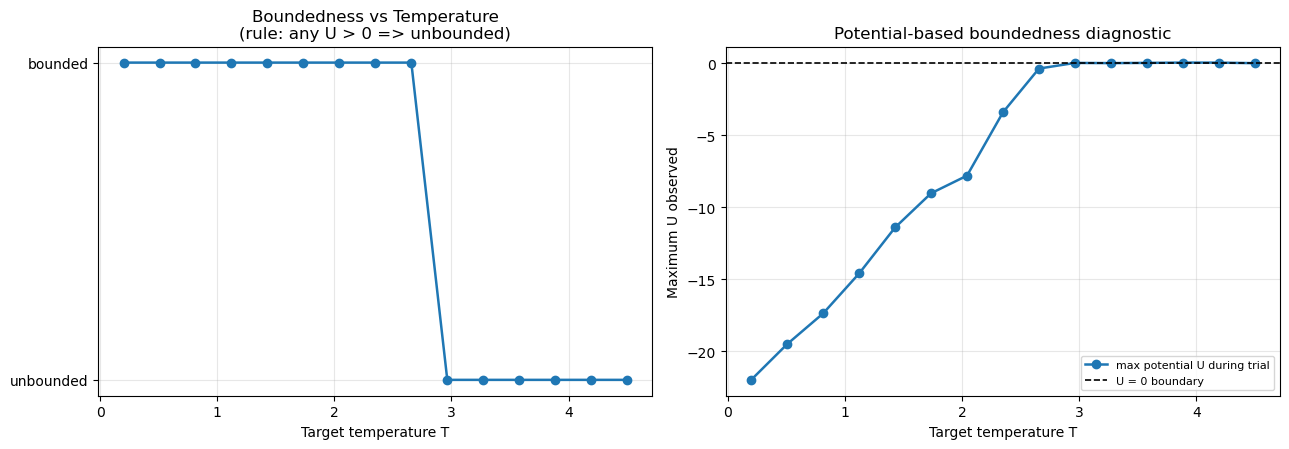

In [24]:
# Start particles at the Lennard-Jones minimum and find the highest temperature
# for which the trajectory remains bounded.
# New rule: if a trial contains ANY single positive potential value (U > 0),
# the system is classified as unbounded.

# LJ minimum spacing: dU/dr = 0  ->  r_min = 2^(1/6) * sigma
r_min = 2.0 ** (1.0 / 6.0) * sigma
N_eq = N
L_eq = N_eq * r_min
x_eq = np.arange(N_eq, dtype=float) * r_min

print(f"LJ minimum spacing r_min = {r_min:.6f}")
print(f"Using periodic box length L_eq = N*r_min = {L_eq:.6f}")
print("Boundedness rule: any U > 0 at any step => unbounded")


def init_velocities_from_temperature(T_target, N, m, k_B, seed):
    rng_local = np.random.default_rng(seed)
    sigma_v = np.sqrt(k_B * T_target / m)
    v0 = rng_local.normal(0.0, sigma_v, size=N)
    v0 -= np.mean(v0)  # remove center-of-mass drift

    # Rescale so initial sampled temperature matches T_target exactly
    T_sample = m * np.mean(v0 * v0) / k_B
    if T_sample > 0:
        v0 *= np.sqrt(T_target / T_sample)
    return v0


def simulate_bounded_check(T_target, seed=1234, n_steps_test=12000, dt_test=2.0e-4):
    x = x_eq.copy()
    v = init_velocities_from_temperature(T_target, N_eq, m, k_B, seed)

    f, U = forces_and_potential_1d(x, L_eq, epsilon, sigma, rc)
    a = f / m

    Tmin = np.inf
    Tmax = -np.inf
    max_U = U

    # Include initial condition in the criterion
    if U > 0.0:
        return {
            "bounded": False,
            "reason": f"positive potential encountered at step 0 (U={U:.4f})",
            "Tmin": np.nan,
            "Tmax": np.nan,
            "max_U": U,
        }

    for step in range(n_steps_test):
        x = np.mod(x + v * dt_test + 0.5 * a * dt_test * dt_test, L_eq)
        f_new, U = forces_and_potential_1d(x, L_eq, epsilon, sigma, rc)
        a_new = f_new / m
        v = v + 0.5 * (a + a_new) * dt_test
        a = a_new

        KE = 0.5 * m * np.sum(v * v)
        T_inst = 2.0 * KE / (N_eq * k_B)
        Tmin = min(Tmin, T_inst)
        Tmax = max(Tmax, T_inst)
        max_U = max(max_U, U)

        # Strict boundedness rule from your request
        if U > 0.0:
            return {
                "bounded": False,
                "reason": f"positive potential at step {step+1} (U={U:.4f})",
                "Tmin": Tmin,
                "Tmax": Tmax,
                "max_U": max_U,
            }

        if not np.isfinite(U + T_inst + np.sum(x) + np.sum(v)):
            return {
                "bounded": False,
                "reason": "non-finite values",
                "Tmin": Tmin,
                "Tmax": Tmax,
                "max_U": max_U,
            }

    return {
        "bounded": True,
        "reason": "U remained <= 0 for all steps",
        "Tmin": Tmin,
        "Tmax": Tmax,
        "max_U": max_U,
    }


# Temperature sweep
T_grid = np.linspace(0.2, 4.5, 15)
bounded_flags = []
reasons = []
Tmin_list = []
Tmax_list = []
Umax_list = []

for i, T_try in enumerate(T_grid):
    out = simulate_bounded_check(T_try, seed=700 + i)
    bounded_flags.append(out["bounded"])
    reasons.append(out["reason"])
    Tmin_list.append(out["Tmin"])
    Tmax_list.append(out["Tmax"])
    Umax_list.append(out["max_U"])
    status = "bounded" if out["bounded"] else "unbounded"
    print(f"T={T_try:.2f} -> {status:9s} | {out['reason']}")

bounded_flags = np.array(bounded_flags, dtype=bool)
Tmin_list = np.array(Tmin_list, dtype=float)
Tmax_list = np.array(Tmax_list, dtype=float)
Umax_list = np.array(Umax_list, dtype=float)

if np.any(bounded_flags):
    T_bounded_max = float(np.max(T_grid[bounded_flags]))
    print(f"\nHighest bounded temperature in tested range: T ≈ {T_bounded_max:.3f}")
else:
    T_bounded_max = np.nan
    print("\nNo bounded temperature found in the tested range.")

if np.any(~bounded_flags):
    T_first_unbounded = float(T_grid[np.where(~bounded_flags)[0][0]])
    print(f"First unbounded temperature in sweep: T ≈ {T_first_unbounded:.3f}")
else:
    print("All tested temperatures remained bounded in this sweep.")

# Diagnostic plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(T_grid, bounded_flags.astype(int), 'o-', lw=1.8)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['unbounded', 'bounded'])
axes[0].set_xlabel('Target temperature T')
axes[0].set_title('Boundedness vs Temperature\n(rule: any U > 0 => unbounded)')
axes[0].grid(alpha=0.3)

axes[1].plot(T_grid, Umax_list, 'o-', label='max potential U during trial', lw=1.8)
axes[1].axhline(0.0, color='black', ls='--', lw=1.2, label='U = 0 boundary')
axes[1].set_xlabel('Target temperature T')
axes[1].set_ylabel('Maximum U observed')
axes[1].set_title('Potential-based boundedness diagnostic')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### JC: The book is correct that it remains bounded until the temperature is raised, but the temperature at which it changes to be unbounded is different. I have a feeling this has to do with the starting values of LEQ and other starting conditions. Of to the 2D version.